# Model Evaluation
## 1. Load, Clean & Feature Engineering

In [3]:
from feature_engineering import load_and_clean_data, engineer_features

df_clean = load_and_clean_data(
    dataset_path="data/df_clean.csv",
)
df_model = engineer_features(df_clean)

print("--- SAMPLE OUTPUT ---")
display(df_model.head())

--- 1. LOADING AND FILTERING DATA ---
ORIGINAL COLUMNS:['time', 'generation biomass', 'generation fossil brown coal/lignite', 'generation fossil gas', 'generation fossil hard coal', 'generation fossil oil', 'generation hydro pumped storage consumption', 'generation hydro run-of-river and poundage', 'generation hydro water reservoir', 'generation nuclear', 'generation other', 'generation other renewable', 'generation solar', 'generation waste', 'generation wind onshore', 'total load actual', 'price day ahead', 'price actual', 'temp_national', 'temp_min_national', 'temp_max_national', 'pressure_national', 'humidity_national', 'wind_speed_national', 'wind_deg_national', 'rain_1h_national', 'snow_3h_national', 'clouds_all_national', 'weather_id_national']
Data loading complete. Retained columns: ['total load actual', 'price day ahead', 'price actual', 'temp_national']

--- 2. FEATURE ENGINEERING ---
Generating system memory features (lags & rolling)...
Building smart weather features (HDH,

,total load actual,temp_national,lag_price_24,load_lag_24,load_lag_168,load_rolling_mean_7d,load_rolling_mean_24h,load_std_24h,load_diff_24h,HDH,...,day_of_week,hour_sin,hour_cos,month_sin,month_cos,is_holiday,next_day_is_holiday,is_bridge_day,day_length_h,is_daylight
time,,,,,,,,,,,,,,,,,,,,,
2015-01-08 22:00:00+00:00,26436.0,1.99686,75.07,30477.0,26798.0,26569.744048,32105.000000,3750.439313,3056.0,13.00314,...,3,-0.500000,0.866025,0.5,0.866025,0,0,0,9.433333,0
2015-01-08 23:00:00+00:00,27485.0,2.01451,73.73,26788.0,27070.0,26578.095238,31949.583333,3893.615185,-3730.0,12.98549,...,3,-0.258819,0.965926,0.5,0.866025,0,0,0,9.450000,0
2015-01-09 00:00:00+00:00,25750.0,1.83200,70.99,25146.0,24935.0,26582.642857,31810.500000,4078.041516,-3338.0,13.16800,...,4,0.000000,1.000000,0.5,0.866025,0,0,0,9.450000,0
2015-01-09 01:00:00+00:00,24760.0,1.68315,68.30,23889.0,23214.0,26589.517857,31679.791667,4283.174412,-3137.0,13.31685,...,4,0.258819,0.965926,0.5,0.866025,0,0,0,9.450000,0
2015-01-09 02:00:00+00:00,24188.0,1.90336,64.22,23046.0,22540.0,26599.994048,31546.375000,4503.907519,-3202.0,13.09664,...,4,0.500000,0.866025,0.5,0.866025,0,0,0,9.450000,0


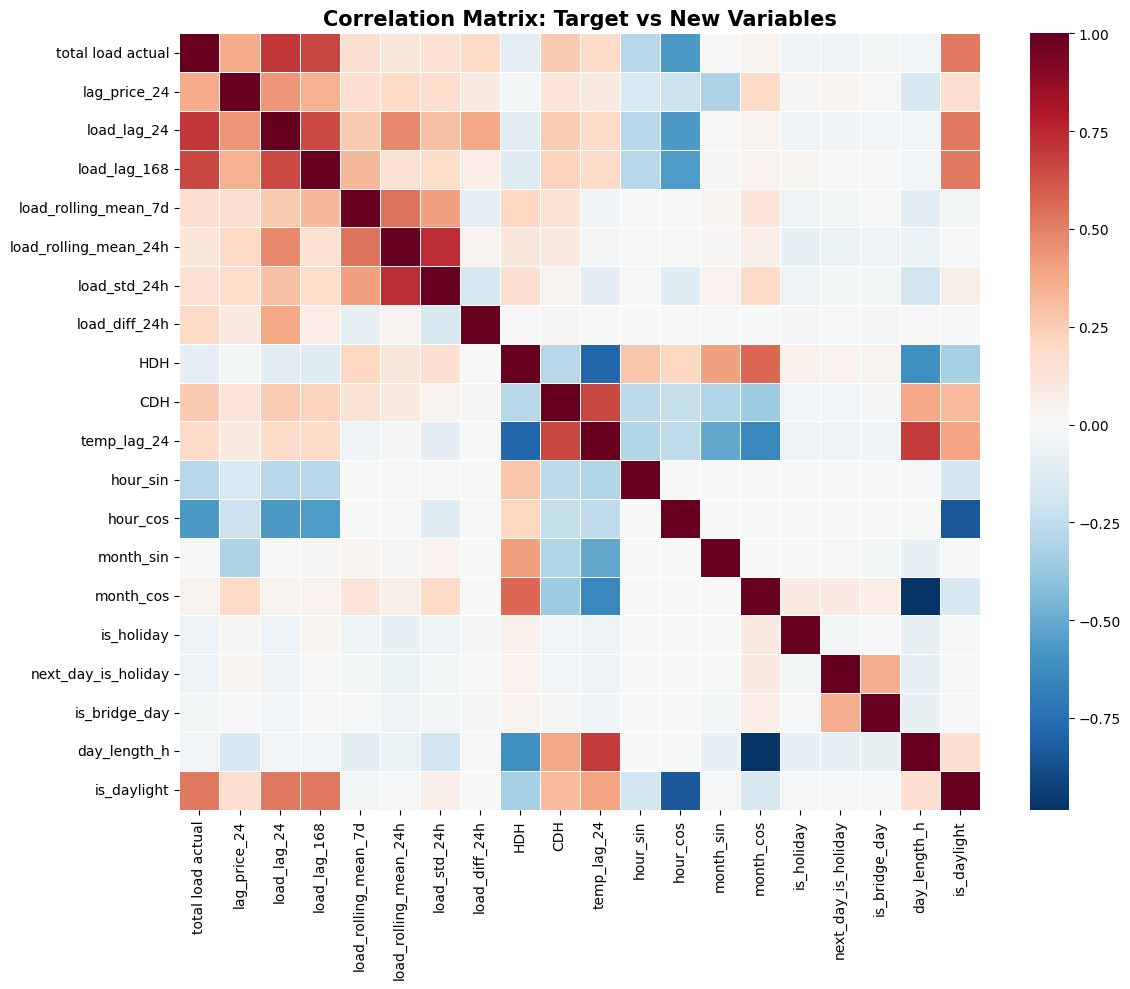

--- Ranking de Correlación con 'total load actual' ---
                       total load actual
total load actual               1.000000
load_lag_24                     0.703438
load_lag_168                    0.660911
is_daylight                     0.520041
lag_price_24                    0.369173
CDH                             0.260552
load_diff_24h                   0.197254
temp_lag_24                     0.189089
load_rolling_mean_7d            0.169915
load_std_24h                    0.148817
load_rolling_mean_24h           0.116932
month_cos                       0.035737
month_sin                       0.007141
is_bridge_day                  -0.023952
day_length_h                   -0.034241
next_day_is_holiday            -0.055187
is_holiday                     -0.059036
HDH                            -0.100496
hour_sin                       -0.277565
hour_cos                       -0.565752


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

new_features = [
    'total load actual',
    'lag_price_24',
    'load_lag_24', 'load_lag_168',
    'load_rolling_mean_7d', 'load_rolling_mean_24h',
    'load_std_24h', 'load_diff_24h',
    'HDH', 'CDH', 'temp_lag_24',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'is_holiday', 'next_day_is_holiday', 'is_bridge_day',
    'day_length_h', 'is_daylight'
]

existing_features = [f for f in new_features if f in df_model.columns]

corr_matrix = df_model[existing_features].corr()

target_corr = corr_matrix[['total load actual']].sort_values(by='total load actual', ascending=False)

plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix, 
            annot=False,
            cmap='RdBu_r', 
            center=0,
            linewidths=0.5)

plt.title("Correlation Matrix: Target vs New Variables", fontweight='bold', fontsize=15)
plt.tight_layout()
plt.show()

print("--- Ranking de Correlación con 'total load actual' ---")
print(target_corr)

## 2. Train / Test Split & TSO Baseline

Splitting data at cutoff date: 2018-01-01 00:00:00+00:00
  Training set: 26,114 hours (2015-01-08 to 2017-12-31)
  Testing set:  8,759 hours (2018-01-01 to 2018-12-31)

Calculating official TSO baseline metrics...
OFFICIAL TSO BASELINE (2018):
   MAE:  269.85 MWh
   MAPE: 0.926 %
   RMSE: 389.32 MWh


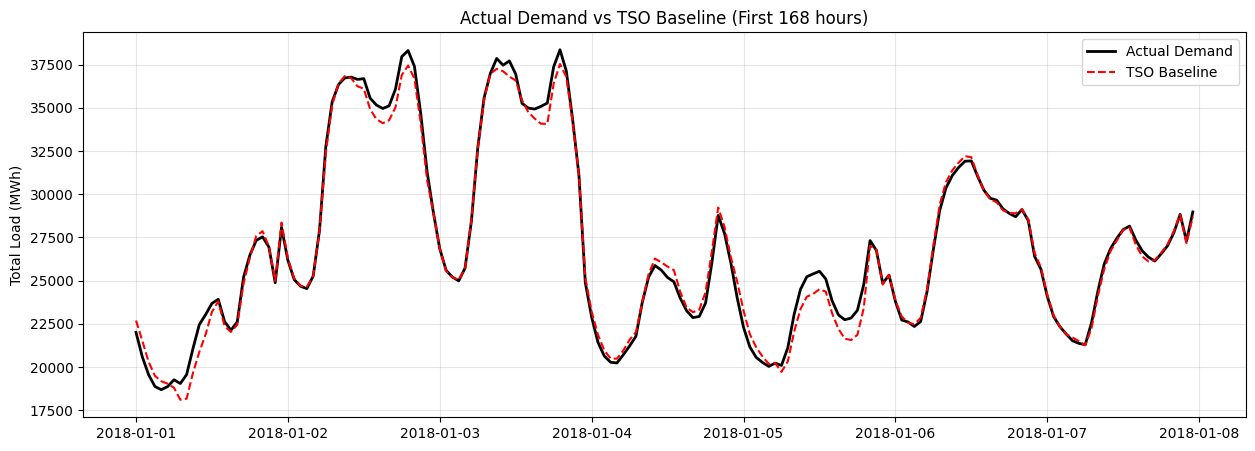

In [5]:
from evaluate import temporal_train_test_split, evaluate_tso_baseline, plot_forecast_vs_actual

X_train, X_test, y_train, y_test = temporal_train_test_split(
    df=df_model,
    target_col="total load actual",
    cutoff_date="2018-01-01 00:00:00+00:00",
)

tso_forecast, tso_metrics = evaluate_tso_baseline(
    y_test=y_test,
    energy_csv_path="data/energy_dataset.csv",
)

plot_forecast_vs_actual(y_actual=y_test, y_pred=tso_forecast,
                        model_name="TSO Baseline", window_hours=168)

## 3. XGBoost

In [ ]:
from modeling_ml import tune_xgboost_with_cv, evaluate_xgboost, plot_xgb_feature_importance

best_xgb = tune_xgboost_with_cv(X_train, y_train, n_iter=10)
xgb_preds, xgb_metrics = evaluate_xgboost(best_xgb, X_test, y_test, tso_metrics=tso_metrics)
plot_xgb_feature_importance(best_xgb, X_train, top_n=20)

--- XGBoost: TIME SERIES CV HYPERPARAMETER SEARCH ---
Running 10 random combinations × 5 folds …
Fitting 5 folds for each of 10 candidates, totalling 50 fits


## 4. LightGBM (Probabilistic)


--- LightGBM: QUANTILE REGRESSION ---
Training median model (α=0.50)…
Training lower bound  (α=0.10)…
Training upper bound  (α=0.90)…

📊 LightGBM Median — TEST SET 2018
  MAE  : 1,463.74 MWh  (▲1,193.89 vs TSO)
  MAPE : 5.022 %
  RMSE : 2,254.81 MWh

--- INTERVAL METRICS ---
  Target coverage : 80%
  PICP            : 52.99%  ⚠️  below target
  MPIW            : 2,538.85 MWh
  Winkler score   : 8,300.63 MWh  (lower = better)


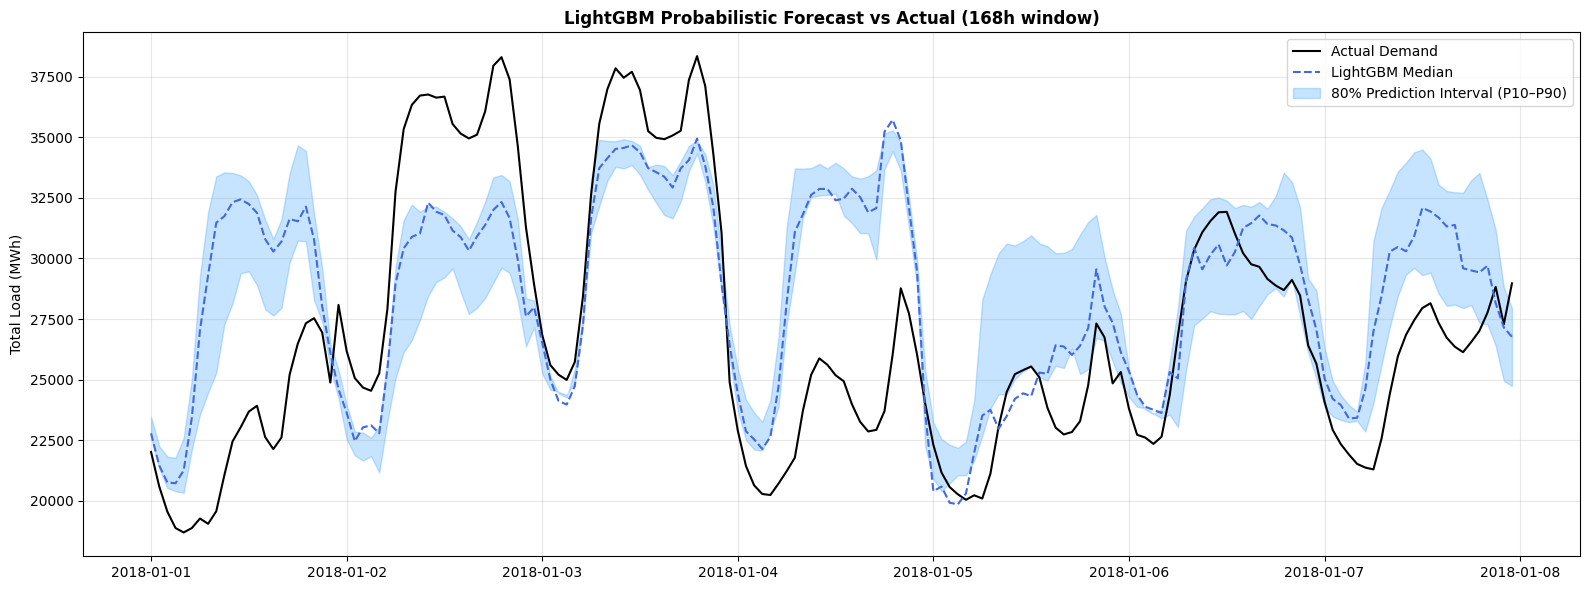

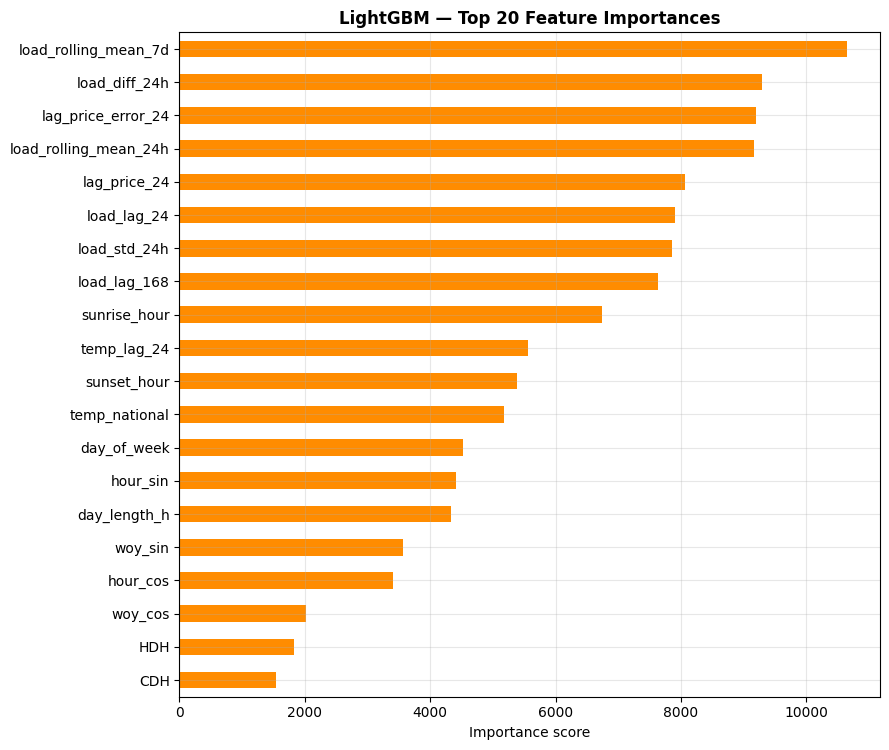

In [4]:
from modeling_ml import (
    train_and_evaluate_lgbm_quantiles,
    evaluate_prediction_intervals,
    plot_lightgbm_intervals,
    plot_lgbm_feature_importance,
)

df_quantiles, best_lgbm, lgbm_metrics = train_and_evaluate_lgbm_quantiles(
    X_train, y_train, X_test, y_test, tso_metrics=tso_metrics,
)

interval_metrics = evaluate_prediction_intervals(df_quantiles, target_coverage=0.80)

plot_lightgbm_intervals(df_quantiles, window_hours=168, start_idx=0)
plot_lgbm_feature_importance(best_lgbm, X_train, top_n=20)

## 5. Alternative Models (CatBoost / MLP / Random Forest)

In [5]:
from modeling_ml import train_alternative_models

alt_preds, alt_metrics = train_alternative_models(
    X_train, y_train, X_test, y_test, tso_metrics=tso_metrics,
)


--- ALTERNATIVE MODELS ---
Training CatBoost…
Training MLP (Neural Network)…
Training Random Forest…

ALTERNATIVE MODELS — TEST SET 2018
Model          |        MAE |  MAPE (%) |       RMSE
----------------------------------------------------
TSO (goal)     |     269.85 |     0.926 |     389.32  ← baseline
----------------------------------------------------
CatBoost       |    1497.21 |     5.130 |    2274.69
MLP            |    1857.87 |     6.439 |    2550.01
RandomForest   |    1559.14 |     5.355 |    2342.00


## 6. Deep Learning Fleet

In [6]:
from modeling_dl import prepare_darts_from_split, train_and_evaluate_deep_learning_fleet

darts_dataset = prepare_darts_from_split(X_train, y_train, X_test, y_test)

predictions, leaderboard = train_and_evaluate_deep_learning_fleet(
    darts_dataset,
    lookback_hours=168,
    horizon=24,
    max_epochs=60,
    tso_metrics=tso_metrics,   # live TSO comparison in leaderboard
)

The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.


--- 1. PREPARING DARTS DATA FROM EXISTING TRAIN/TEST SPLIT ---
  Future covariates : 14 columns (Calendario + Solar)
  Past covariates   : 5 columns (Clima real)
  Scaling (fit on train, transform test)...
Darts data preparation complete.

LAUNCHING DEEP LEARNING FLEET


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.



──────────────────────────────────────────────────
TRAINING LSTM
──────────────────────────────────────────────────


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 54.0 K

...

Validation: |          | 0/? [00:00<?, ?it/s]

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


💾 Saved to saved_models/N-HiTS_model.pt (10 epochs)
Running historical_forecasts for N-HiTS...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


✅ N-HiTS | MAE: 1,418.94 MWh | MAPE: 4.831% | RMSE: 2,076.17 MWh
📈 Loss curves → saved_models/N-HiTS_loss_curves.csv

🏆 DEEP LEARNING LEADERBOARD — TEST SET 2018
Model        |  MAE (MWh) |  MAPE (%) |  RMSE (MWh)
------------------------------------------------------------
TSO (goal)   |     269.85 |     0.926 |      389.32  ← baseline
------------------------------------------------------------
N-HiTS       |    1418.94 |     4.831 |     2076.17
LSTM         |    1539.32 |     5.265 |     2293.65
GRU          |    1636.17 |     5.576 |     2340.03
N-BEATS      |    1671.61 |     5.558 |     2368.79
TCN          |    1712.52 |     5.942 |     2527.41

📁 Configs saved → saved_models/fleet_configs.json


### 6.1 Loss Curves

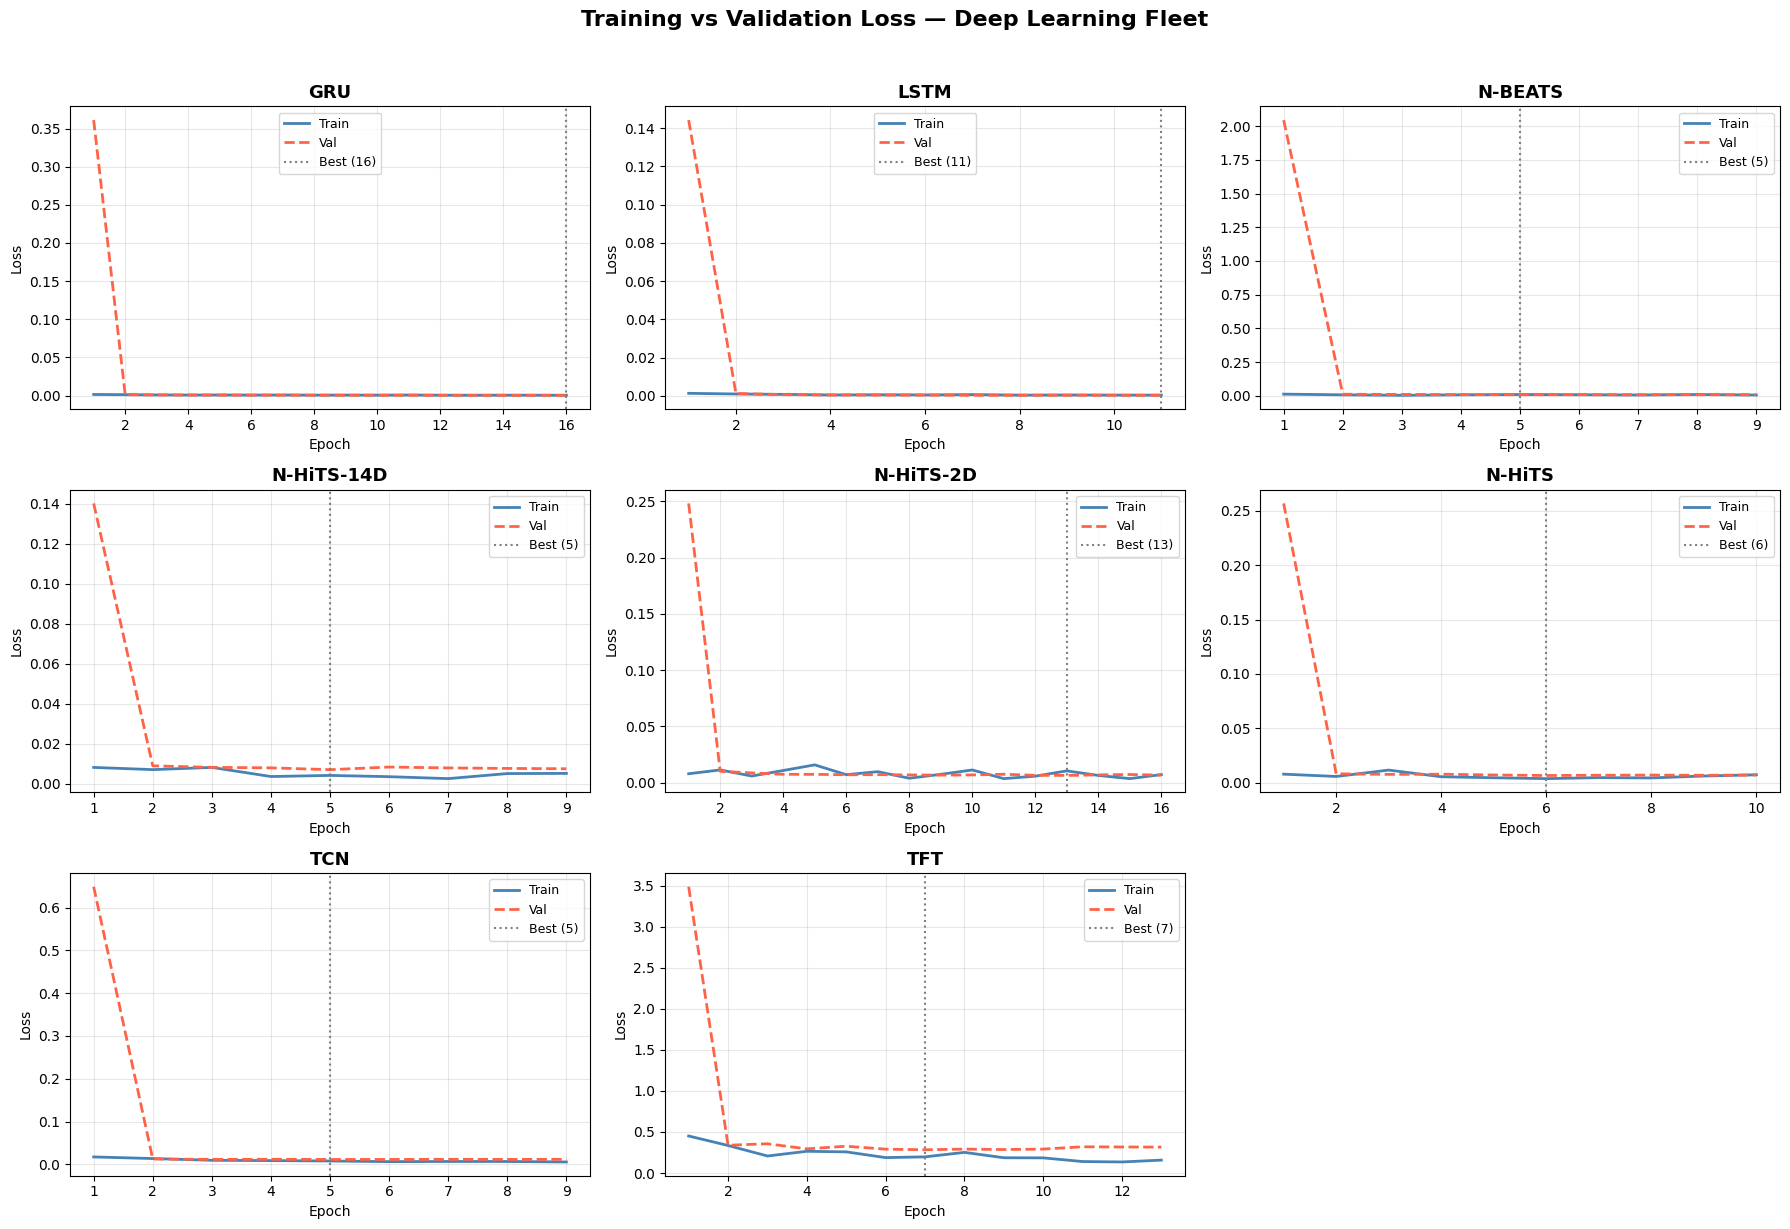

In [7]:
from modeling_dl import plot_saved_loss_curves
plot_saved_loss_curves()

### 6.2 Best Model Visualisation

Best model: N-HiTS


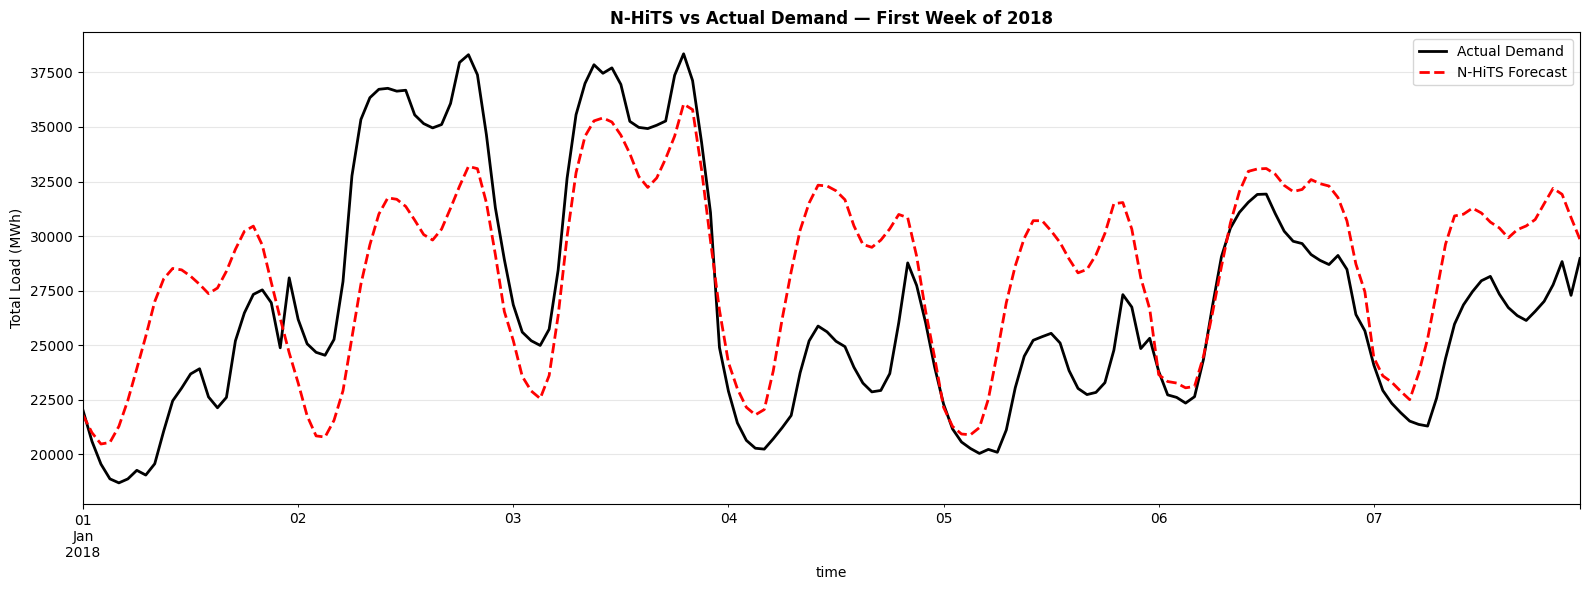

In [8]:
import matplotlib.pyplot as plt

top_name = leaderboard[0][0]
print(f"Best model: {top_name}")

actuals_ts = darts_dataset["test_target_unscaled"]

plt.figure(figsize=(16, 6))
actuals_ts[:168].plot(label="Actual Demand", color="black", linewidth=2)
predictions[top_name][:168].plot(label=f"{top_name} Forecast", color="red", linestyle="--")
plt.title(f"{top_name} vs Actual Demand — First Week of 2018", fontweight="bold")
plt.ylabel("Total Load (MWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Error Analysis (Best Model)

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

top_model_name = leaderboard[0][0]
print(f"Running error analysis for: {top_model_name}")

actuals_df = darts_dataset["test_target_unscaled"].to_dataframe()
preds_df   = predictions[top_model_name].to_dataframe()

error_df = actuals_df.join(preds_df, how="inner", lsuffix="_actual", rsuffix="_pred")
error_df.columns = ["Actual_Demand", "Predicted_Demand"]
error_df["Error"]            = error_df["Predicted_Demand"] - error_df["Actual_Demand"]
error_df["Absolute_Error"]   = error_df["Error"].abs()
error_df["Percentage_Error"] = error_df["Absolute_Error"] / error_df["Actual_Demand"] * 100
error_df["Hour"]             = error_df.index.hour
error_df["DayOfWeek"]        = error_df.index.day_name()
error_df["Date"]             = error_df.index.date
error_df["Season"]           = error_df.index.month.map({
    12:"Winter",1:"Winter",2:"Winter",
    3:"Spring",4:"Spring",5:"Spring",
    6:"Summer",7:"Summer",8:"Summer",
    9:"Autumn",10:"Autumn",11:"Autumn",
})

Running error analysis for: N-HiTS


### 7.1 Worst Days

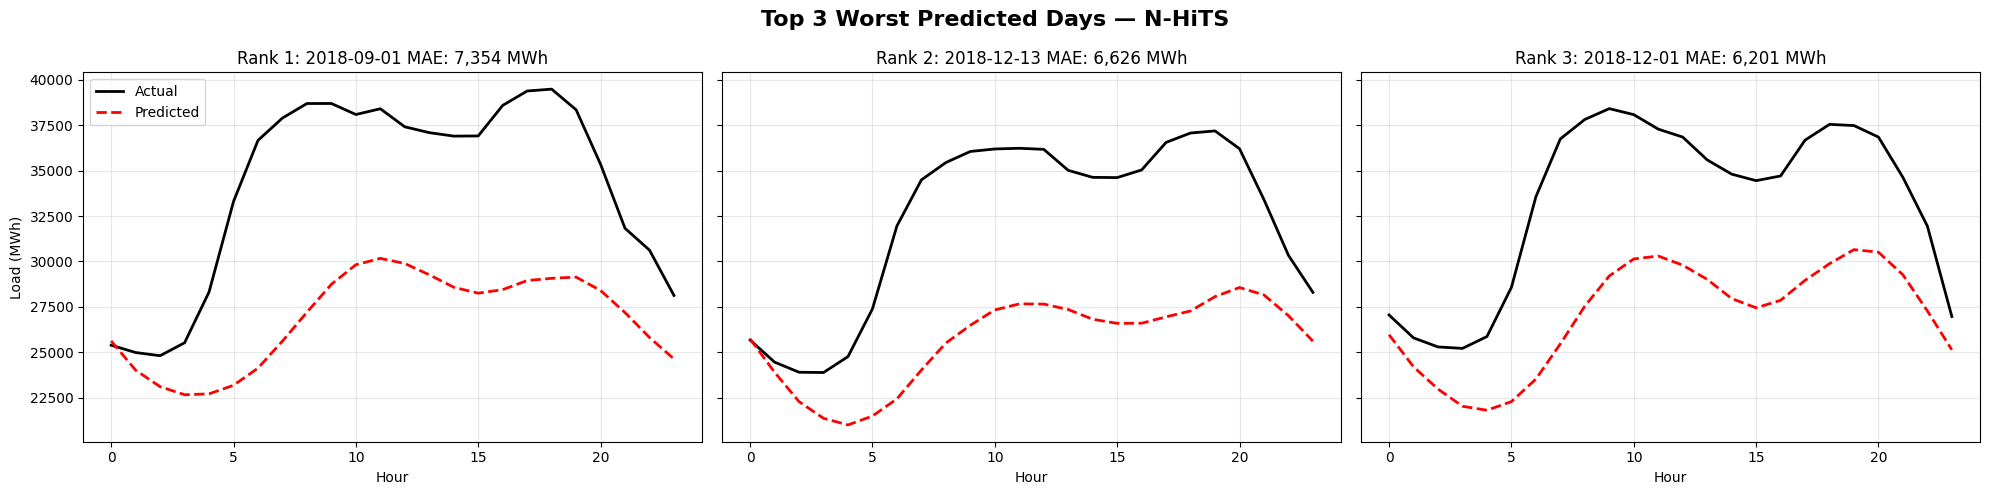

In [10]:
daily_mae = error_df.groupby("Date")["Absolute_Error"].mean().sort_values(ascending=False)
worst_3 = daily_mae.head(3)

fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)
fig.suptitle(f"Top 3 Worst Predicted Days — {top_model_name}", fontsize=16, fontweight="bold")
for i, (date, mae_val) in enumerate(worst_3.items()):
    day_data = error_df[error_df["Date"] == date]
    axes[i].plot(day_data.index.hour, day_data["Actual_Demand"], color="black", lw=2, label="Actual")
    axes[i].plot(day_data.index.hour, day_data["Predicted_Demand"], color="red", linestyle="--", lw=2, label="Predicted")
    axes[i].set_title(f"Rank {i+1}: {date} MAE: {mae_val:,.0f} MWh")
    axes[i].set_xlabel("Hour")
    axes[i].grid(True, alpha=0.3)
    if i == 0:
        axes[i].set_ylabel("Load (MWh)")
        axes[i].legend()
plt.tight_layout()
plt.show()

### 7.2 Systematic Bias

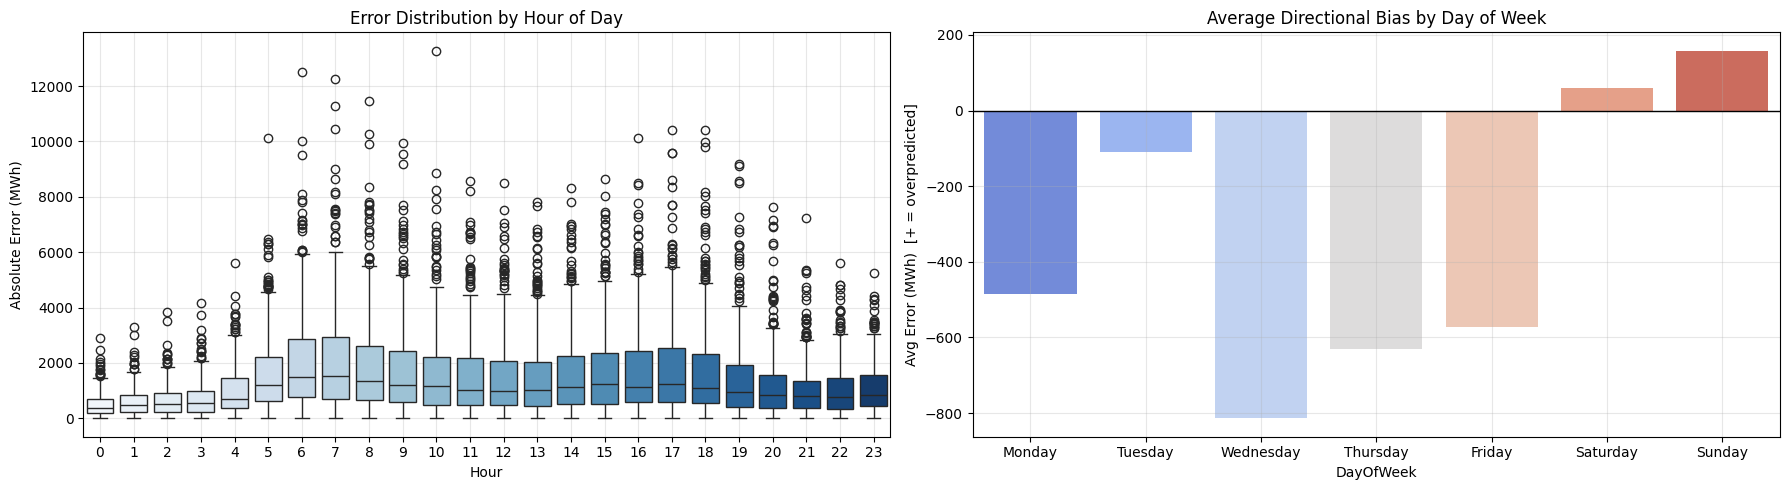

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

sns.boxplot(data=error_df, x="Hour", y="Absolute_Error", ax=axes[0], palette="Blues")
axes[0].set_title("Error Distribution by Hour of Day")
axes[0].set_ylabel("Absolute Error (MWh)")
axes[0].grid(True, alpha=0.3)

sns.barplot(data=error_df, x="DayOfWeek", y="Error", order=day_order,
            ax=axes[1], palette="coolwarm", errorbar=None)
axes[1].set_title("Average Directional Bias by Day of Week")
axes[1].set_ylabel("Avg Error (MWh)  [+ = overpredicted]")
axes[1].axhline(0, color="black", lw=1)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.3 Error Drivers

Top 10 features correlated with large errors:
load_lag_24           0.185453
load_lag_168          0.167246
is_daylight           0.155864
woy_cos               0.110832
month_cos             0.110654
sunrise_hour          0.101560
HDH                   0.093120
lag_price_error_24    0.089871
load_std_24h          0.085192
Hour                  0.081288


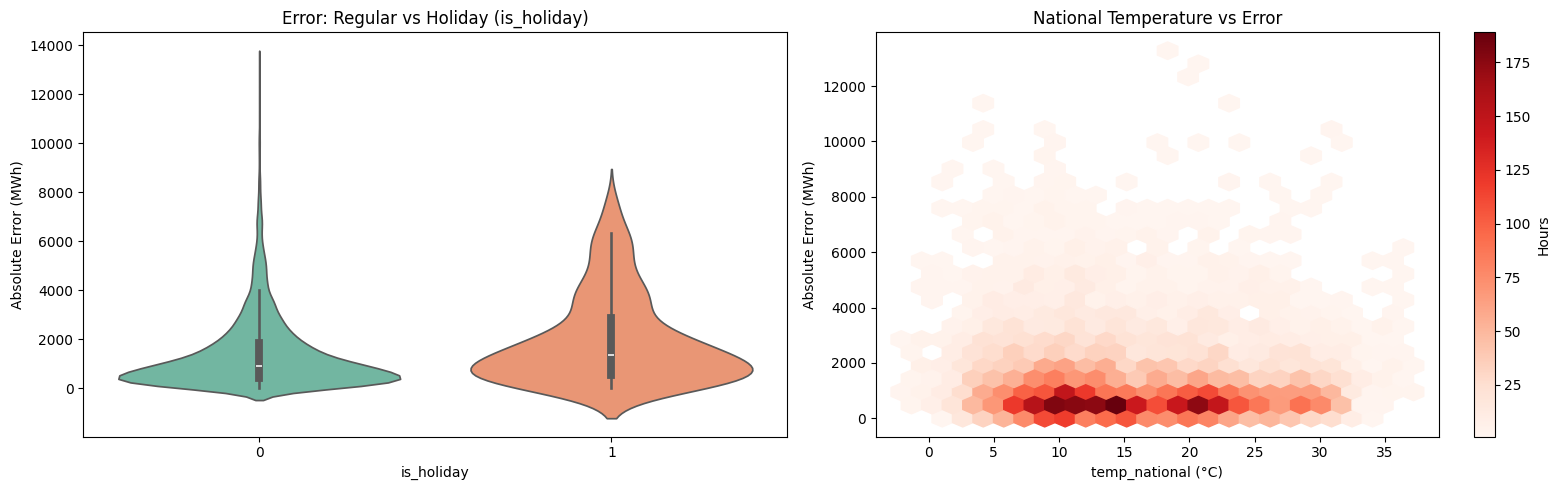

In [12]:
# Join with features for correlation analysis
X_test_naive = X_test.copy()
X_test_naive.index = X_test_naive.index.tz_localize(None)
analysis_df = error_df.join(X_test_naive, how="inner")

numeric_cols = analysis_df.select_dtypes(include=[np.number]).columns
error_corr = (
    analysis_df[numeric_cols]
    .corr()["Absolute_Error"]
    .drop(["Error","Absolute_Error","Percentage_Error","Actual_Demand","Predicted_Demand"], errors="ignore")
    .sort_values(ascending=False)
)
print("Top 10 features correlated with large errors:")
print(error_corr.head(10).to_string())

# Holiday impact
hol_cols = [c for c in analysis_df.columns if "holiday" in c.lower()]
temp_cols = [c for c in analysis_df.columns if "temp" in c.lower()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

if hol_cols:
    sns.violinplot(data=analysis_df, x=hol_cols[0], y="Absolute_Error", ax=ax1, palette="Set2")
    ax1.set_title(f"Error: Regular vs Holiday ({hol_cols[0]})")
    ax1.set_ylabel("Absolute Error (MWh)")

if temp_cols:
    hb = ax2.hexbin(analysis_df["temp_national"], analysis_df["Absolute_Error"],
                    gridsize=25, cmap="Reds", mincnt=1)
    ax2.set_title("National Temperature vs Error")
    ax2.set_xlabel("temp_national (°C)")
    ax2.set_ylabel("Absolute Error (MWh)")
    fig.colorbar(hb, ax=ax2, label="Hours")

plt.tight_layout()
plt.show()

## 8. Master Comparison Table

In [13]:
# Aggregate all model results into a single leaderboard
import pandas as pd

all_results = {
    "TSO Baseline":  tso_metrics,
    "XGBoost":       xgb_metrics,
    "LightGBM":      lgbm_metrics,
    **alt_metrics,
}

# Add deep learning results
for name, metrics in leaderboard:
    all_results[f"DL: {name}"] = metrics

comparison_df = pd.DataFrame(all_results).T[["MAE", "MAPE", "RMSE"]]
comparison_df = comparison_df.sort_values("MAE")
comparison_df["vs TSO (MAE)"] = comparison_df["MAE"] - tso_metrics["MAE"]

print(comparison_df.round(2).to_string())
display(comparison_df.style
        .background_gradient(subset=["MAE"], cmap="RdYlGn_r")
        .format({"MAE": "{:,.2f}", "MAPE": "{:.3f}", "RMSE": "{:,.2f}", "vs TSO (MAE)": "{:+,.2f}"}))

                  MAE  MAPE     RMSE  vs TSO (MAE)
TSO Baseline   269.85  0.93   389.32          0.00
DL: N-HiTS    1418.94  4.83  2076.17       1149.09
LightGBM      1463.74  5.02  2254.81       1193.89
CatBoost      1497.21  5.13  2274.69       1227.36
XGBoost       1513.52  5.19  2305.42       1243.67
DL: LSTM      1539.32  5.27  2293.65       1269.47
RandomForest  1559.14  5.36  2342.00       1289.29
DL: GRU       1636.17  5.58  2340.03       1366.32
DL: N-BEATS   1671.61  5.56  2368.79       1401.76
DL: TCN       1712.52  5.94  2527.41       1442.67
MLP           1857.87  6.44  2550.01       1588.02


,MAE,MAPE,RMSE,vs TSO (MAE)
TSO Baseline,269.85,0.926,389.32,+0.00
DL: N-HiTS,"1,418.94",4.831,"2,076.17","+1,149.09"
LightGBM,"1,463.74",5.022,"2,254.81","+1,193.89"
CatBoost,"1,497.21",5.130,"2,274.69","+1,227.36"
XGBoost,"1,513.52",5.190,"2,305.42","+1,243.67"
DL: LSTM,"1,539.32",5.265,"2,293.65","+1,269.47"
RandomForest,"1,559.14",5.355,"2,342.00","+1,289.29"
DL: GRU,"1,636.17",5.576,"2,340.03","+1,366.32"
DL: N-BEATS,"1,671.61",5.558,"2,368.79","+1,401.76"
DL: TCN,"1,712.52",5.942,"2,527.41","+1,442.67"


In [14]:
# ==============================================================================
# 9. ENSEMBLE MODELING (LA BATALLA FINAL)
# ==============================================================================
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt

print("--- ALINEANDO LA ÉLITE (TOP 3) ---")

# 1. Crear DataFrame unificado con las predicciones del Top 3
# (Asegúrate de que 'predictions' es tu diccionario de Darts y los otros son tus ML)
ensemble_df = pd.DataFrame(index=y_test.index)
ensemble_df['Actual'] = y_test.values

# Extraer el ganador de Deep Learning
df_nhits = predictions['N-HiTS'].to_dataframe()
if df_nhits.index.tz is None and ensemble_df.index.tz is not None:
    df_nhits.index = df_nhits.index.tz_localize(ensemble_df.index.tz)
ensemble_df['N-HiTS'] = df_nhits.iloc[:, 0]

# Extraer los reyes del Machine Learning
# (Sustituye 'pred_lgbm' y 'pred_xgb' por tus variables reales)
ensemble_df['LightGBM'] = df_quantiles['Pred_Median'] 
ensemble_df['XGBoost']  = xgb_preds  

# Limpiar posibles desajustes de horas
ensemble_df = ensemble_df.dropna()

def evaluate_ensemble(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name:<25} | MAE: {mae:,.2f} MWh | MAPE: {mape:.3f}%")
    return mae

# -------------------------------------------------------------------------
# ESTRATEGIA 1: INVERSE MAE WEIGHTING (Promedio Ponderado)
# -------------------------------------------------------------------------
model_cols = ['N-HiTS', 'LightGBM', 'XGBoost']
maes = {m: mean_absolute_error(ensemble_df['Actual'], ensemble_df[m]) for m in model_cols}
inv_maes = {m: 1.0 / error for m, error in maes.items()}
sum_inv_maes = sum(inv_maes.values())
weights = {m: inv / sum_inv_maes for m, inv in inv_maes.items()}

print("Pesos asignados por el Ensemble Ponderado:")
for m, w in weights.items():
    print(f"  - {m}: {w:.1%}")

ensemble_df['Ensemble_Weighted'] = sum(ensemble_df[m] * w for m, w in weights.items())

# -------------------------------------------------------------------------
# ESTRATEGIA 2: STACKING (Meta-Learner Ridge)
# -------------------------------------------------------------------------
# Partimos el test set: 2 meses para entrenar al Meta-Learner, el resto para evaluar
train_days = 60 * 24
train_mask = ensemble_df.index < ensemble_df.index[train_days]
test_mask  = ~train_mask

X_stack_train = ensemble_df.loc[train_mask, model_cols]
y_stack_train = ensemble_df.loc[train_mask, 'Actual']

X_stack_test  = ensemble_df.loc[test_mask, model_cols]

# Usamos Ridge (regresión lineal con penalización) para evitar sobreajuste
meta_learner = Ridge(alpha=10.0, positive=True) # Obligamos a pesos positivos
meta_learner.fit(X_stack_train, y_stack_train)

# Predecir el resto del año
ensemble_df.loc[test_mask, 'Ensemble_Stacking'] = meta_learner.predict(X_stack_test)


# -------------------------------------------------------------------------
# EVALUACIÓN FINAL DE ENSEMBLES (A partir del día 60)
# -------------------------------------------------------------------------
eval_df = ensemble_df[test_mask].copy()

print("\n🏆 RESULTADOS FINALES DE LOS ENSEMBLES")
print("-" * 65)
evaluate_ensemble(eval_df['Actual'], eval_df['N-HiTS'], "N-HiTS (Mejor Individual)")
evaluate_ensemble(eval_df['Actual'], eval_df['Ensemble_Weighted'], "Ensemble 1: Ponderado")
evaluate_ensemble(eval_df['Actual'], eval_df['Ensemble_Stacking'], "Ensemble 2: Meta-Learner")

print("-" * 65)

--- ALINEANDO LA ÉLITE (TOP 3) ---
Pesos asignados por el Ensemble Ponderado:
  - N-HiTS: 34.3%
  - LightGBM: 33.4%
  - XGBoost: 32.3%

🏆 RESULTADOS FINALES DE LOS ENSEMBLES
-----------------------------------------------------------------
N-HiTS (Mejor Individual) | MAE: 1,346.88 MWh | MAPE: 4.590%
Ensemble 1: Ponderado     | MAE: 1,262.26 MWh | MAPE: 4.309%
Ensemble 2: Meta-Learner  | MAE: 1,210.21 MWh | MAPE: 4.168%
-----------------------------------------------------------------


--- INICIANDO EL MOTOR DE ENSEMBLE: ALINEANDO LA ÉLITE ---

🏆 COMPARATIVA FINAL DE ENSEMBLES (Evaluado Feb-Dic 2018)
-------------------------------------------------------------------------------------
                           MAE  MAPE     RMSE   vs TSO
TSO Baseline            269.85  0.93   389.32     0.00
Ensemble: MAE Inverso  1217.66  4.16  1869.69   947.81
Ensemble: Media        1217.84  4.16  1869.02   947.99
Ensemble: Mediana      1303.00  4.44  2040.82  1033.15
N-HiTS (Best Solo)     1346.88  4.59  1997.30  1077.03
Ensemble: Stacking     1374.54  4.63  1921.53  1104.69


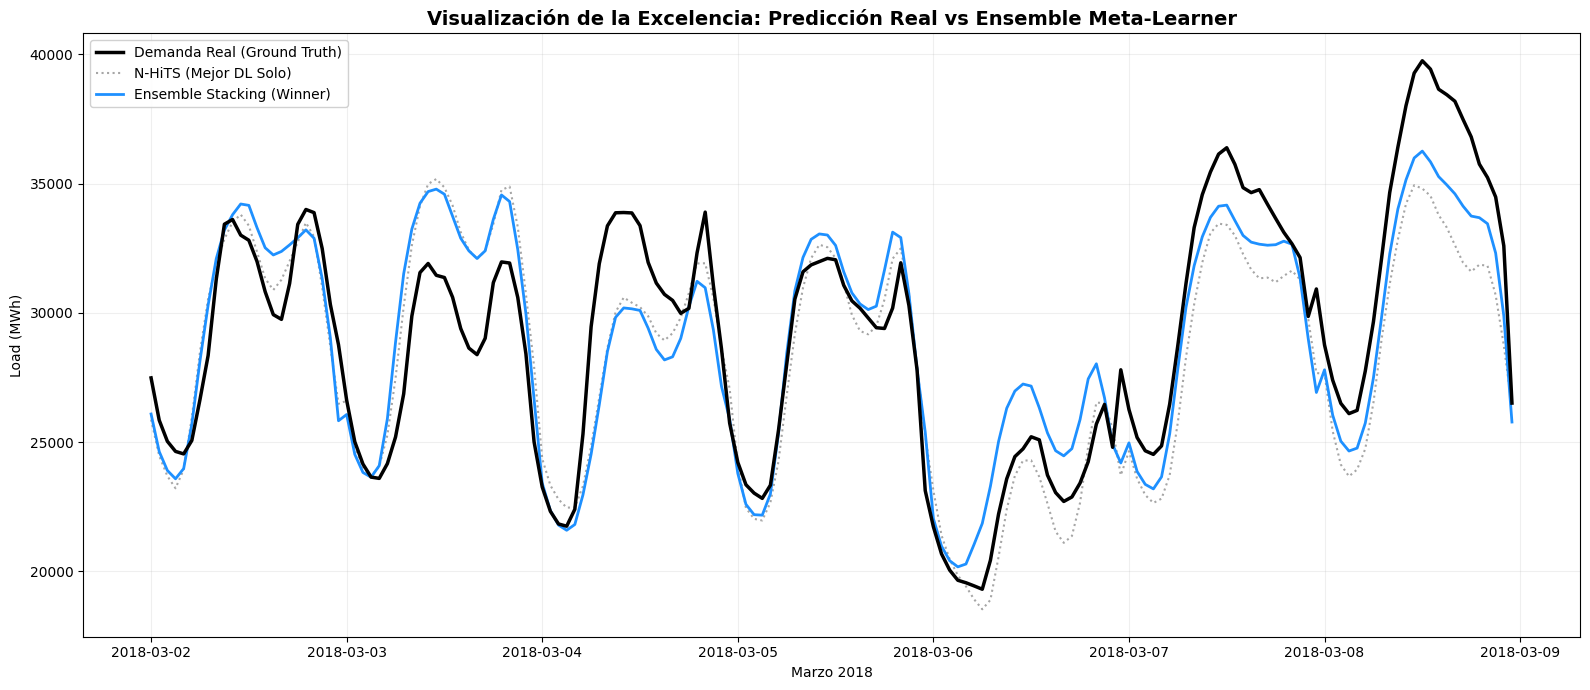


[Insights] Pesos finales del Meta-Learner:
  > N-HiTS: 36.7%
  > GRU: 57.9%
  > LightGBM: 0.0%
  > XGBoost: 3.2%
  > CatBoost: 0.0%


In [15]:
# ==============================================================================
# 9. ENSEMBLE MASTER ENGINE (COMPARTIVA FINAL DE TODAS LAS ESTRATEGIAS)
# ==============================================================================
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt

print("--- INICIANDO EL MOTOR DE ENSEMBLE: ALINEANDO LA ÉLITE ---")

# 1. CONSTRUCCIÓN DEL DATAFRAME UNIFICADO
ensemble_df = pd.DataFrame(index=y_test.index)
ensemble_df['Actual'] = y_test.values

# Extraer y alinear predicciones de Deep Learning (Darts)
# Cogemos N-HiTS y GRU como representantes de DL
for dl_model in ['N-HiTS', 'GRU']:
    if dl_model in predictions:
        df_temp = predictions[dl_model].to_dataframe()
        if df_temp.index.tz is None and ensemble_df.index.tz is not None:
            df_temp.index = df_temp.index.tz_localize(ensemble_df.index.tz)
        ensemble_df[dl_model] = df_temp.iloc[:, 0]

# Extraer y alinear predicciones de Machine Learning
ensemble_df['LightGBM'] = df_quantiles['Pred_Median']
ensemble_df['XGBoost']  = xgb_preds
ensemble_df['CatBoost'] = alt_preds['CatBoost']

# Limpieza por seguridad
ensemble_df = ensemble_df.dropna()
model_cols = ['N-HiTS', 'GRU', 'LightGBM', 'XGBoost', 'CatBoost']

# -------------------------------------------------------------------------
# 2. CÁLCULO DE ESTRATEGIAS DE ENSEMBLE
# -------------------------------------------------------------------------

# A) Promedios Básicos
ensemble_df['Ensemble_Mean']   = ensemble_df[model_cols].mean(axis=1)
ensemble_df['Ensemble_Median'] = ensemble_df[model_cols].median(axis=1)

# B) Ponderación por Error Inverso (Inverse MAE Weighting)
maes = {m: mean_absolute_error(ensemble_df['Actual'], ensemble_df[m]) for m in model_cols}
inv_maes = {m: 1.0 / error for m, error in maes.items()}
sum_inv = sum(inv_maes.values())
weights_inv = {m: inv / sum_inv for m, inv in inv_maes.items()}

ensemble_df['Ensemble_InverseMAE'] = sum(ensemble_df[m] * w for m, w in weights_inv.items())

# C) Meta-Learner (Stacking con Ridge)
# Usamos los primeros 60 días para que el modelo aprenda a combinar
train_size = 60 * 24
train_mask = ensemble_df.index < ensemble_df.index[train_size]
test_mask  = ~train_mask

meta_learner = Ridge(alpha=10.0, positive=True) # Pesos positivos para estabilidad
meta_learner.fit(ensemble_df.loc[train_mask, model_cols], ensemble_df.loc[train_mask, 'Actual'])

# Predecir para el resto del año
ensemble_df.loc[test_mask, 'Ensemble_Stacking'] = meta_learner.predict(ensemble_df.loc[test_mask, model_cols])

# -------------------------------------------------------------------------
# 3. EVALUACIÓN Y LEADERBOARD FINAL
# -------------------------------------------------------------------------
# Solo evaluamos sobre el test_mask (donde el Stacking no ha visto los datos)
eval_df = ensemble_df[test_mask].copy()

def get_metrics(y_true, y_pred):
    return {
        'MAE':  mean_absolute_error(y_true, y_pred),
        'MAPE': mean_absolute_percentage_error(y_true, y_pred) * 100,
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred))
    }

final_leaderboard = {}
final_leaderboard['TSO Baseline'] = tso_metrics
final_leaderboard['N-HiTS (Best Solo)'] = get_metrics(eval_df['Actual'], eval_df['N-HiTS'])

# Añadir todos los ensembles
ensemble_methods = {
    'Ensemble: Media':      'Ensemble_Mean',
    'Ensemble: Mediana':    'Ensemble_Median',
    'Ensemble: MAE Inverso': 'Ensemble_InverseMAE',
    'Ensemble: Stacking':   'Ensemble_Stacking'
}

for label, col in ensemble_methods.items():
    final_leaderboard[label] = get_metrics(eval_df['Actual'], eval_df[col])

# Mostrar Tabla
report_df = pd.DataFrame(final_leaderboard).T[['MAE', 'MAPE', 'RMSE']].sort_values('MAE')
report_df['vs TSO'] = report_df['MAE'] - tso_metrics['MAE']

print("\n🏆 COMPARATIVA FINAL DE ENSEMBLES (Evaluado Feb-Dic 2018)")
print("-" * 85)
print(report_df.round(2).to_string())

# -------------------------------------------------------------------------
# 4. VISUALIZACIÓN: EL COMBATE FINAL
# -------------------------------------------------------------------------
plt.figure(figsize=(16, 7))
plot_window = eval_df.iloc[:168] # Visualizamos una semana

plt.plot(plot_window.index, plot_window['Actual'], label='Demanda Real (Ground Truth)', color='black', lw=2.5, zorder=3)
plt.plot(plot_window.index, plot_window['N-HiTS'], label='N-HiTS (Mejor DL Solo)', color='gray', ls=':', alpha=0.7)
plt.plot(plot_window.index, plot_window['Ensemble_Stacking'], label='Ensemble Stacking (Winner)', color='dodgerblue', lw=2)

plt.title("Visualización de la Excelencia: Predicción Real vs Ensemble Meta-Learner", fontsize=14, fontweight='bold')
plt.ylabel("Load (MWh)")
plt.xlabel("Marzo 2018")
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Imprimir Pesos del Stacking para el informe
print("\n[Insights] Pesos finales del Meta-Learner:")
for m, coef in zip(model_cols, meta_learner.coef_):
    print(f"  > {m}: {coef:.1%}")